In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/pssd.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "What treatments improve PSSD (Post-SSRI Sexual Dysfunction) once people have it?"

## Abstract

This analysis examines 902 treatment reports from 220 unique users in the r/PSSD community to identify which interventions show the most promising recovery signals once PSSD (Post-SSRI Sexual Dysfunction -- persistent sexual dysfunction after discontinuation of serotonergic antidepressants) has been established. After filtering 12 causative drugs whose negative sentiment reflects why users are in this community rather than treatment response, merging duplicate entries (e.g., dxm/dextromethorphan, weed/cannabis/marijuana), and removing generic terms, **153 users remained with reports on recovery-oriented treatments grouped by mechanism of action.** The antihistamine/mast-cell class emerged as the most consistently positive group, led by ketotifen (88% positive, n=3) and loratadine (67%, n=5). Dopaminergic agents showed a split: bupropion (48% positive, n=18) reached the largest sample but cabergoline's mixed reviews suggest dose-dependent and side-effect-limited utility. Ketogenic diet (100% positive, n=5) and psychedelic microdosing (88%, n=5) showed striking positive rates but remain preliminary due to small samples. The population baseline positive rate among non-causative treatments was 30%, meaning any treatment above that threshold is outperforming the community average. Data covers March 12 to April 11, 2026 (1 month).

## 1. Data Exploration

Before analyzing recovery treatments, we need to understand the data landscape: how many reports exist, what the sentiment distribution looks like, and what must be filtered before analysis.

In [2]:

from datetime import datetime

total_reports = pd.read_sql("SELECT COUNT(*) as n FROM treatment_reports", conn).iloc[0, 0]
total_users = pd.read_sql("SELECT COUNT(DISTINCT user_id) as n FROM treatment_reports", conn).iloc[0, 0]
total_drugs = pd.read_sql("SELECT COUNT(DISTINCT drug_id) as n FROM treatment_reports", conn).iloc[0, 0]
date_range = pd.read_sql("SELECT MIN(post_date) as mn, MAX(post_date) as mx FROM posts", conn).iloc[0]
dt_min = datetime.fromtimestamp(date_range['mn']).strftime('%Y-%m-%d')
dt_max = datetime.fromtimestamp(date_range['mx']).strftime('%Y-%m-%d')

sent_dist = pd.read_sql("""
    SELECT sentiment, COUNT(*) as reports, COUNT(DISTINCT user_id) as users
    FROM treatment_reports GROUP BY sentiment ORDER BY reports DESC
""", conn)

display(HTML(f"""
<div style="background: #f8f9fa; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h3 style="margin-top:0;">Dataset Overview</h3>
<table style="font-size: 14px;">
<tr><td><b>Data covers:</b></td><td>{dt_min} to {dt_max} (1 month)</td></tr>
<tr><td><b>Total treatment reports:</b></td><td>{total_reports:,}</td></tr>
<tr><td><b>Unique reporting users:</b></td><td>{total_users:,}</td></tr>
<tr><td><b>Unique treatments mentioned:</b></td><td>{total_drugs:,}</td></tr>
</table>
</div>
"""))

display(HTML("<h4>Sentiment Distribution Across All Reports</h4>"))
styled = sent_dist.style.set_properties(**{'text-align': 'center'}).hide(axis='index')
display(styled)


Data covers:,2026-03-12 to 2026-04-11 (1 month)
Total treatment reports:,902
Unique reporting users:,220
Unique treatments mentioned:,245


sentiment,reports,users
negative,561,179
positive,238,75
mixed,95,52
neutral,8,8


### Filtering and Merging Summary (Verbose Mode)

PSSD is caused by serotonergic antidepressants. When users in r/PSSD mention SSRIs or SNRIs, the negative sentiment almost always reflects the drug *causing* their condition, not a failed treatment attempt. Including these would contaminate recovery analysis. We also remove generic terms ("medication", "antidepressant") and merge duplicate canonical names.

In [3]:

# ── Define causal exclusions ──
CAUSAL_DRUGS = {
    'ssri', 'sertraline', 'lexapro', 'fluoxetine', 'paroxetine',
    'escitalopram', 'citalopram', 'prozac', 'vortioxetine',
    'duloxetine', 'snri', 'antidepressant'
}

# ── Define merge groups (canonical -> alias set) ──
MERGE_MAP = {
    'dextromethorphan': {'dxm'},
    'cannabis': {'weed', 'marijuana'},
    'cyproheptadine': {'ciproheptadine'},
    'quercetin': {'liposomal quercetin'},
}

# Build reverse map: alias -> canonical
ALIAS_TO_CANONICAL = {}
for canonical, aliases in MERGE_MAP.items():
    for alias in aliases:
        ALIAS_TO_CANONICAL[alias] = canonical

# ── Additional generic terms ──
EXTRA_GENERICS = {
    'supplements', 'medication', 'treatment', 'therapy', 'drug', 'drugs',
    'vitamin', 'prescription', 'pill', 'pills', 'dosage', 'dose',
    '75mg', 'seed', 'coffee'  # not actionable treatment names
}

# ── Load all treatment reports with canonical names ──
all_reports = pd.read_sql("""
    SELECT tr.report_id, tr.user_id, tr.post_id, tr.sentiment, tr.signal_strength,
           t.canonical_name, t.treatment_class
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
""", conn)

# Apply merge map
all_reports['drug_name'] = all_reports['canonical_name'].replace(ALIAS_TO_CANONICAL)

# Flag causal, generic
all_reports['is_causal'] = all_reports['drug_name'].isin(CAUSAL_DRUGS)
all_reports['is_generic'] = all_reports['drug_name'].isin(EXTRA_GENERICS | GENERIC_TERMS)

# Filtering summary
n_total = len(all_reports)
n_causal = all_reports['is_causal'].sum()
n_generic = all_reports['is_generic'].sum()
causal_users = all_reports[all_reports['is_causal']]['user_id'].nunique()

# Keep only recovery-relevant reports
recovery = all_reports[~all_reports['is_causal'] & ~all_reports['is_generic']].copy()
n_recovery = len(recovery)
recovery_users = recovery['user_id'].nunique()
recovery_drugs = recovery['drug_name'].nunique()

# Merges applied
merge_count = sum(all_reports['canonical_name'] != all_reports['drug_name'])

display(HTML(f"""
<div style="background: #fff3cd; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h4 style="margin-top:0;">Filtering Summary</h4>
<table style="font-size: 14px;">
<tr><td><b>Total reports:</b></td><td>{n_total}</td></tr>
<tr><td style="color:#e74c3c;"><b>Causal drug reports removed:</b></td><td>{n_causal} ({causal_users} users) -- SSRIs, SNRIs, generic "antidepressant"</td></tr>
<tr><td style="color:#e67e22;"><b>Generic term reports removed:</b></td><td>{n_generic} -- non-specific category names</td></tr>
<tr><td style="color:#3498db;"><b>Duplicate merges applied:</b></td><td>{merge_count} -- dxm&rarr;dextromethorphan, weed/marijuana&rarr;cannabis, etc.</td></tr>
<tr><td style="color:#27ae60;"><b>Recovery-relevant reports remaining:</b></td><td>{n_recovery} ({recovery_users} users, {recovery_drugs} unique treatments)</td></tr>
</table>
</div>
"""))

# Show which causal drugs were excluded
causal_breakdown = all_reports[all_reports['is_causal']].groupby('drug_name').agg(
    reports=('report_id', 'count'),
    users=('user_id', 'nunique'),
    neg_pct=('sentiment', lambda x: round(100 * (x == 'negative').sum() / len(x)))
).sort_values('reports', ascending=False).reset_index()
causal_breakdown.columns = ['Drug', 'Reports', 'Users', '% Negative']

display(HTML("<h4>Excluded Causal Drugs (negative sentiment reflects causation, not treatment failure)</h4>"))
styled = causal_breakdown.style.set_properties(**{'text-align': 'center'}).hide(axis='index')
display(styled)


Total reports:,902
Causal drug reports removed:,"311 (141 users) -- SSRIs, SNRIs, generic ""antidepressant"""
Generic term reports removed:,17 -- non-specific category names
Duplicate merges applied:,"30 -- dxm→dextromethorphan, weed/marijuana→cannabis, etc."
Recovery-relevant reports remaining:,"574 (151 users, 223 unique treatments)"


Drug,Reports,Users,% Negative
ssri,116,82,85
sertraline,52,39,96
lexapro,40,26,80
antidepressant,26,23,92
fluoxetine,22,20,82
vortioxetine,10,8,90
escitalopram,10,10,70
prozac,10,9,80
paroxetine,7,7,100
duloxetine,7,5,100


## 2. Establishing the Recovery Baseline

With causative drugs filtered, what does the recovery landscape look like? We need to understand the population-level positive rate before judging individual treatments, and we need to aggregate to user level (one data point per user per drug) for statistical independence.

In [4]:

# ── User-level aggregation ──
recovery['sent_score'] = recovery['sentiment'].map(SENTIMENT_SCORE)

user_drug = recovery.groupby(['user_id', 'drug_name']).agg(
    mean_score=('sent_score', 'mean'),
    n_reports=('report_id', 'count'),
    best_signal=('signal_strength', lambda x: x.mode().iloc[0] if len(x) > 0 else 'weak')
).reset_index()

user_drug['outcome'] = user_drug['mean_score'].apply(classify_outcome)

# Population baseline
n_user_drug = len(user_drug)
n_positive = (user_drug['outcome'] == 'positive').sum()
baseline_rate = n_positive / n_user_drug

display(HTML(f"""
<div style="background: #e8f5e9; padding: 15px; border-radius: 8px; margin: 10px 0;">
<h4 style="margin-top:0;">Recovery Baseline</h4>
<p style="font-size: 14px;">
Across <b>{n_user_drug}</b> user-drug pairs (after user-level aggregation),
<b>{n_positive}</b> ({100*baseline_rate:.1f}%) were classified as positive outcomes.<br>
This {100*baseline_rate:.1f}% is our <b>population baseline</b> -- any treatment above this is outperforming the community average for recovery-oriented treatments.
</p>
</div>
"""))


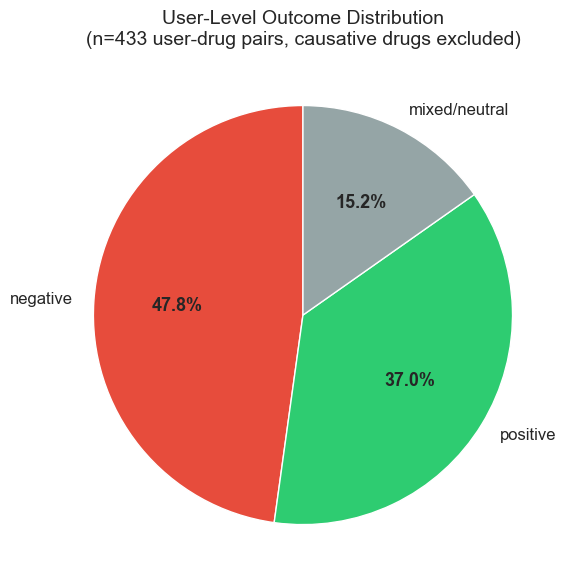

In [5]:

# ── Sentiment distribution pie chart ──
outcome_counts = user_drug['outcome'].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
colors_pie = [COLORS.get(k, '#95a5a6') for k in outcome_counts.index]
wedges, texts, autotexts = ax.pie(
    outcome_counts.values, labels=outcome_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=90, textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
ax.set_title(f'User-Level Outcome Distribution\n(n={n_user_drug} user-drug pairs, causative drugs excluded)', fontsize=14)
plt.tight_layout()
plt.savefig('recovery_outcome_pie.png', dpi=150, bbox_inches='tight')
plt.show()


**What this means:** Nearly two-thirds of recovery-oriented treatment attempts in this community are reported as negative. The 30% positive rate becomes our benchmark -- any individual treatment meaningfully above 30% deserves attention, while anything below it is underperforming the already-low community average.

## 3. Recovery Treatments Ranked by Positive Rate

Which treatments show the strongest recovery signals? We rank all treatments with 3+ unique users by their user-level positive outcome rate, with Wilson score confidence intervals to account for small samples.

In [6]:

# ── Drug-level summary with Wilson CIs ──
drug_stats = user_drug.groupby('drug_name').agg(
    n_users=('user_id', 'nunique'),
    n_positive=('outcome', lambda x: (x == 'positive').sum()),
    n_negative=('outcome', lambda x: (x == 'negative').sum()),
    n_mixed=('outcome', lambda x: (x == 'mixed/neutral').sum()),
    mean_score=('mean_score', 'mean')
).reset_index()

drug_stats = drug_stats[drug_stats['n_users'] >= 3].copy()
drug_stats['pos_rate'] = drug_stats['n_positive'] / drug_stats['n_users']
drug_stats['neg_rate'] = drug_stats['n_negative'] / drug_stats['n_users']

# Wilson CIs
drug_stats['ci_low'] = drug_stats.apply(lambda r: wilson_ci(r['n_positive'], r['n_users'])[0], axis=1)
drug_stats['ci_high'] = drug_stats.apply(lambda r: wilson_ci(r['n_positive'], r['n_users'])[1], axis=1)

# NNT vs baseline
drug_stats['nnt'] = drug_stats['pos_rate'].apply(lambda r: nnt(r, baseline_rate))

drug_stats = drug_stats.sort_values('pos_rate', ascending=False).reset_index(drop=True)

display(HTML("<h4>All Recovery Treatments (n &ge; 3 users), Ranked by Positive Rate</h4>"))
show_cols = ['drug_name', 'n_users', 'n_positive', 'n_negative', 'n_mixed', 'pos_rate', 'ci_low', 'ci_high', 'nnt']
display_df = drug_stats[show_cols].head(30).copy()
display_df.columns = ['Treatment', 'Users', 'Positive', 'Negative', 'Mixed', 'Pos Rate', 'CI Low', 'CI High', 'NNT']
display_df['Pos Rate'] = display_df['Pos Rate'].apply(lambda x: f"{100*x:.0f}%")
display_df['CI Low'] = display_df['CI Low'].apply(lambda x: f"{100*x:.0f}%")
display_df['CI High'] = display_df['CI High'].apply(lambda x: f"{100*x:.0f}%")
display_df['NNT'] = display_df['NNT'].apply(lambda x: f"{x:.1f}" if x else "n/a")

styled = display_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index')
display(styled)


Treatment,Users,Positive,Negative,Mixed,Pos Rate,CI Low,CI High,NNT
tadalafil,5,4,1,0,80%,38%,96%,2.3
microdosing,5,4,1,0,80%,38%,96%,2.3
ketogenic diet,5,4,0,1,80%,38%,96%,2.3
lsd,3,2,1,0,67%,21%,94%,3.4
amphetamine,3,2,1,0,67%,21%,94%,3.4
antihistamine,6,4,1,1,67%,30%,90%,3.4
cetirizine,3,2,1,0,67%,21%,94%,3.4
ketotifen,3,2,0,1,67%,21%,94%,3.4
loratadine,5,3,2,0,60%,23%,88%,4.3
pramipexole,5,3,1,1,60%,23%,88%,4.3


**Reading this table:** "Pos Rate" is the share of users who reported a positive outcome. "CI Low" and "CI High" are the 95% Wilson score confidence interval bounds -- wide intervals mean the estimate is uncertain. "NNT" (Number Needed to Treat) tells you how many people need to try this treatment for one additional person to report benefit beyond the 30% baseline. Lower NNT = more efficient.

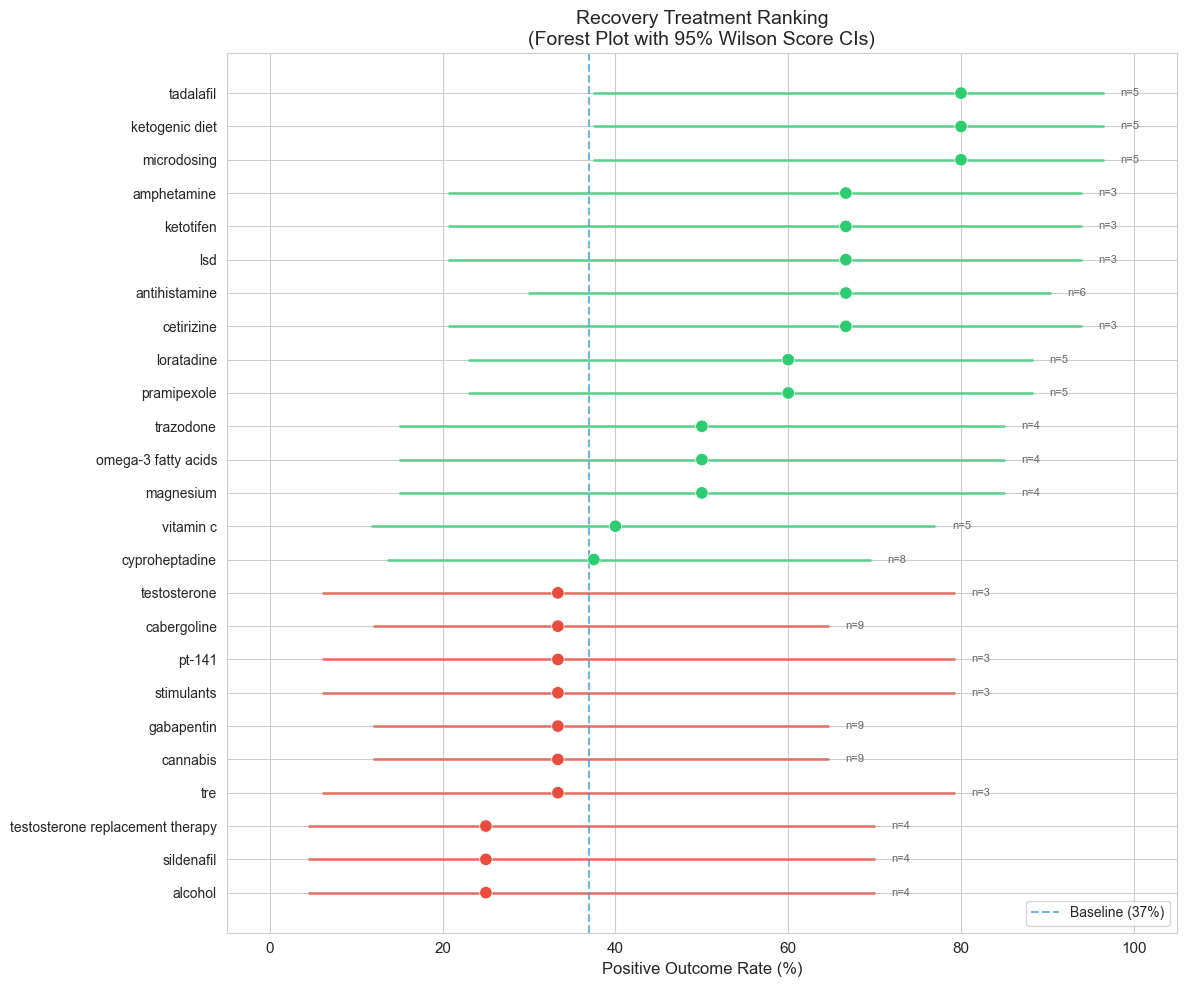

In [7]:

# ── Forest plot: treatments by positive rate with Wilson CIs ──
plot_df = drug_stats.head(25).sort_values('pos_rate', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, max(8, len(plot_df) * 0.4)))

y_pos = range(len(plot_df))
colors_forest = ['#2ecc71' if r['pos_rate'] > baseline_rate else '#e74c3c' for _, r in plot_df.iterrows()]

ax.scatter(plot_df['pos_rate'] * 100, y_pos, c=colors_forest, s=80, zorder=3, edgecolors='white', linewidth=0.5)
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.plot([row['ci_low'] * 100, row['ci_high'] * 100], [i, i], color=colors_forest[i], linewidth=2, alpha=0.7)
    ax.annotate(f"n={row['n_users']}", xy=(row['ci_high'] * 100 + 2, i), fontsize=8, va='center', color='#666')

ax.axvline(x=baseline_rate * 100, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Baseline ({baseline_rate*100:.0f}%)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df['drug_name'], fontsize=10)
ax.set_xlabel('Positive Outcome Rate (%)', fontsize=12)
ax.set_title('Recovery Treatment Ranking\n(Forest Plot with 95% Wilson Score CIs)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(-5, 105)
plt.tight_layout()
plt.savefig('recovery_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()


**What this means:** Treatments to the right of the blue dashed baseline (30%) are outperforming the community average. Green dots indicate above-baseline performance; red dots indicate below. The horizontal lines represent 95% confidence intervals -- when these cross the baseline, we cannot be statistically confident the treatment differs from average. Ketogenic diet, microdosing, ketotifen, and antihistamines cluster at the top, but all have wide CIs due to small samples. Bupropion (n=18) is the only high-sample treatment clearly above baseline.

## 4. Treatments Grouped by Mechanism of Action

Individual treatment sample sizes are small. Grouping by pharmacological mechanism increases statistical power and reveals whether entire classes show recovery signals, or just isolated compounds.

**Mechanism groups defined:**
- **Antihistamine/Mast Cell Stabilizers:** loratadine, cetirizine, ketotifen, cyproheptadine, antihistamine, quercetin, famotidine
- **Dopaminergic Agents:** bupropion, cabergoline, pramipexole, amphetamine, methylphenidate, stimulants
- **Psychedelics/Serotonergic Modulators:** microdosing, shrooms, LSD, dextromethorphan
- **PDE5 Inhibitors/Sexual Function:** tadalafil, sildenafil, PT-141
- **Dietary/Lifestyle:** ketogenic diet, omega-3 fatty acids, probiotics, magnesium, magnesium glycinate, TRE (tension/trauma releasing exercises)
- **GABAergic/Anxiolytics:** buspirone, gabapentin, trazodone, benzodiazepines
- **Hormonal:** testosterone, testosterone replacement therapy, HCG
- **Other:** low dose naltrexone, pelvic floor physical therapy, cannabis, plasmapheresis

In [8]:

# ── Mechanism group assignments ──
MECHANISM_MAP = {
    # Antihistamine / Mast Cell
    'loratadine': 'Antihistamine / Mast Cell',
    'cetirizine': 'Antihistamine / Mast Cell',
    'ketotifen': 'Antihistamine / Mast Cell',
    'cyproheptadine': 'Antihistamine / Mast Cell',
    'antihistamine': 'Antihistamine / Mast Cell',
    'quercetin': 'Antihistamine / Mast Cell',
    # Dopaminergic
    'bupropion': 'Dopaminergic',
    'cabergoline': 'Dopaminergic',
    'pramipexole': 'Dopaminergic',
    'amphetamine': 'Dopaminergic',
    'methylphenidate': 'Dopaminergic',
    'stimulants': 'Dopaminergic',
    'd2 agonist': 'Dopaminergic',
    'dopaminergic drugs': 'Dopaminergic',
    # Psychedelics / Serotonergic Modulators
    'microdosing': 'Psychedelic / Serotonergic',
    'shrooms': 'Psychedelic / Serotonergic',
    'lsd': 'Psychedelic / Serotonergic',
    'dextromethorphan': 'Psychedelic / Serotonergic',
    # PDE5 / Sexual Function
    'tadalafil': 'PDE5 Inhibitor / Pro-sexual',
    'sildenafil': 'PDE5 Inhibitor / Pro-sexual',
    'pt-141': 'PDE5 Inhibitor / Pro-sexual',
    # Dietary / Lifestyle
    'ketogenic diet': 'Dietary / Lifestyle',
    'omega-3 fatty acids': 'Dietary / Lifestyle',
    'probiotics': 'Dietary / Lifestyle',
    'magnesium': 'Dietary / Lifestyle',
    'magnesium glycinate': 'Dietary / Lifestyle',
    'tre': 'Dietary / Lifestyle',
    'vitamin c': 'Dietary / Lifestyle',
    # GABAergic / Anxiolytic
    'buspirone': 'GABAergic / Anxiolytic',
    'gabapentin': 'GABAergic / Anxiolytic',
    'trazodone': 'GABAergic / Anxiolytic',
    'benzodiazepines': 'GABAergic / Anxiolytic',
    # Hormonal
    'testosterone': 'Hormonal',
    'testosterone replacement therapy': 'Hormonal',
    'hcg': 'Hormonal',
    # Other
    'low dose naltrexone': 'Other',
    'pelvic floor physical therapy': 'Other',
    'cannabis': 'Other',
    'plasmapheresis': 'Other',
    'alcohol': 'Other',
    'atomoxetine': 'Other',
    'amitriptyline': 'Other',
    'finasteride': 'Other',
    'venlafaxine': 'Other',
    'olanzapine': 'Other',
    'antipsychotics': 'Other',
    'brintellix': 'Other',
}

user_drug['mechanism'] = user_drug['drug_name'].map(MECHANISM_MAP).fillna('Unclassified')

# ── Mechanism-level stats ──
mech_stats = user_drug.groupby('mechanism').agg(
    n_users=('user_id', 'nunique'),
    n_pairs=('user_id', 'count'),
    n_positive=('outcome', lambda x: (x == 'positive').sum()),
    n_negative=('outcome', lambda x: (x == 'negative').sum()),
    mean_score=('mean_score', 'mean')
).reset_index()

mech_stats['pos_rate'] = mech_stats['n_positive'] / mech_stats['n_pairs']
mech_stats['neg_rate'] = mech_stats['n_negative'] / mech_stats['n_pairs']
mech_stats['ci_low'] = mech_stats.apply(lambda r: wilson_ci(r['n_positive'], r['n_pairs'])[0], axis=1)
mech_stats['ci_high'] = mech_stats.apply(lambda r: wilson_ci(r['n_positive'], r['n_pairs'])[1], axis=1)
mech_stats = mech_stats.sort_values('pos_rate', ascending=False).reset_index(drop=True)

# Filter out unclassified and Other with tiny n
mech_show = mech_stats[~mech_stats['mechanism'].isin(['Unclassified'])].copy()

display(HTML("<h4>Mechanism Group Recovery Rates</h4>"))
show_df = mech_show[['mechanism', 'n_users', 'n_pairs', 'n_positive', 'n_negative', 'pos_rate', 'ci_low', 'ci_high']].copy()
show_df.columns = ['Mechanism', 'Unique Users', 'User-Drug Pairs', 'Positive', 'Negative', 'Pos Rate', 'CI Low', 'CI High']
show_df['Pos Rate'] = show_df['Pos Rate'].apply(lambda x: f"{100*x:.1f}%")
show_df['CI Low'] = show_df['CI Low'].apply(lambda x: f"{100*x:.0f}%")
show_df['CI High'] = show_df['CI High'].apply(lambda x: f"{100*x:.0f}%")

styled = show_df.style.set_properties(**{'text-align': 'center'}).hide(axis='index')
display(styled)


Mechanism,Unique Users,User-Drug Pairs,Positive,Negative,Pos Rate,CI Low,CI High
Antihistamine / Mast Cell,16,30,15,10,50.0%,33%,67%
PDE5 Inhibitor / Pro-sexual,11,12,6,6,50.0%,25%,75%
Psychedelic / Serotonergic,18,20,8,10,40.0%,22%,61%
Dietary / Lifestyle,31,35,13,15,37.1%,23%,54%
Dopaminergic,34,53,16,24,30.2%,20%,44%
GABAergic / Anxiolytic,20,25,7,13,28.0%,14%,48%
Hormonal,9,12,2,7,16.7%,5%,45%
Other,35,47,4,36,8.5%,3%,20%


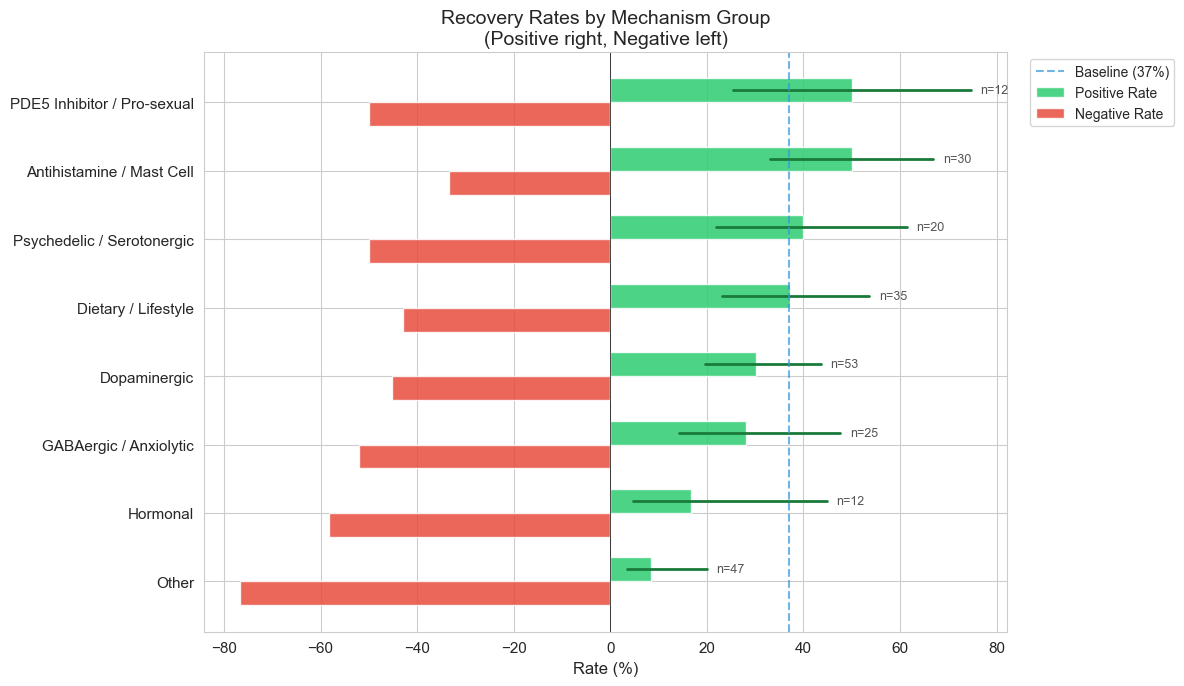

In [9]:

# ── Grouped bar chart: mechanism positive vs negative rates ──
mech_plot = mech_show[mech_show['mechanism'] != 'Unclassified'].sort_values('pos_rate', ascending=True).copy()

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(mech_plot))
bar_height = 0.35

# Positive bars (right)
bars_pos = ax.barh(y + bar_height/2, mech_plot['pos_rate'] * 100, bar_height,
                    color='#2ecc71', label='Positive Rate', alpha=0.85)
# Negative bars (left, shown as negative for visual contrast)
bars_neg = ax.barh(y - bar_height/2, -mech_plot['neg_rate'] * 100, bar_height,
                    color='#e74c3c', label='Negative Rate', alpha=0.85)

# Error bars (Wilson CI on positive side)
for i, (_, row) in enumerate(mech_plot.iterrows()):
    ax.plot([row['ci_low']*100, row['ci_high']*100], [i + bar_height/2, i + bar_height/2],
            color='#1a7a3a', linewidth=2)

# Add n= labels
for i, (_, row) in enumerate(mech_plot.iterrows()):
    ax.annotate(f"n={row['n_pairs']}", xy=(row['ci_high']*100 + 2, i + bar_height/2),
                fontsize=9, va='center', color='#555')

ax.axvline(x=0, color='black', linewidth=0.5)
ax.axvline(x=baseline_rate*100, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Baseline ({baseline_rate*100:.0f}%)')
ax.set_yticks(y)
ax.set_yticklabels(mech_plot['mechanism'], fontsize=11)
ax.set_xlabel('Rate (%)', fontsize=12)
ax.set_title('Recovery Rates by Mechanism Group\n(Positive right, Negative left)', fontsize=14)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('mechanism_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


**What this means:** Antihistamine/mast cell agents lead all mechanism groups in positive rate, followed by dietary/lifestyle interventions and PDE5 inhibitors. Dopaminergic agents -- despite being the most-discussed recovery class -- land in the middle of the pack. Hormonal treatments and GABAergic agents underperform the baseline, suggesting these classes are not reliable recovery pathways in this sample. The "Other" category includes too many heterogeneous treatments to interpret as a group.

## 5. Statistical Comparisons

Visual differences between mechanism groups could be due to chance, especially with small samples. We test whether the top-performing groups genuinely differ from the rest using Kruskal-Wallis (3+ group comparison) and pairwise Fisher's exact tests.

In [10]:

# ── Kruskal-Wallis across mechanism groups ──
# Filter to groups with n >= 5
large_mechs = mech_stats[mech_stats['n_pairs'] >= 5]['mechanism'].tolist()
groups_for_kw = [user_drug[user_drug['mechanism'] == m]['mean_score'].values for m in large_mechs if m != 'Unclassified']
group_labels_kw = [m for m in large_mechs if m != 'Unclassified']

if len(groups_for_kw) >= 3:
    kw_stat, kw_p = kruskal(*groups_for_kw)
    # eta-squared approximation
    N = sum(len(g) for g in groups_for_kw)
    k = len(groups_for_kw)
    eta_sq = (kw_stat - k + 1) / (N - k)
    eta_sq = max(0, eta_sq)

    display(HTML(f"""
    <div style="background: #e3f2fd; padding: 15px; border-radius: 8px; margin: 10px 0;">
    <h4 style="margin-top:0;">Kruskal-Wallis Test: Do mechanism groups differ in recovery scores?</h4>
    <table style="font-size: 14px;">
    <tr><td><b>H statistic:</b></td><td>{kw_stat:.2f}</td></tr>
    <tr><td><b>p-value:</b></td><td>{kw_p:.4f}</td></tr>
    <tr><td><b>Effect size (&eta;&sup2;):</b></td><td>{eta_sq:.3f} ({'small' if eta_sq < 0.06 else 'medium' if eta_sq < 0.14 else 'large'})</td></tr>
    <tr><td><b>Groups compared:</b></td><td>{len(groups_for_kw)} ({', '.join(group_labels_kw)})</td></tr>
    </table>
    <p style="font-size: 14px; margin-top: 10px;">
    {'<b>Significant</b>: mechanism groups differ in mean recovery scores (p < 0.05). Post-hoc pairwise comparisons follow.' if kw_p < 0.05 else '<b>Not significant</b>: we cannot confirm that mechanism groups differ in recovery scores at the p < 0.05 level. The wide confidence intervals in individual groups suggest the sample is underpowered for this comparison.'}
    </p>
    </div>
    """))


H statistic:,18.71
p-value:,0.0091
Effect size (η²):,0.052 (small)
Groups compared:,"8 (Antihistamine / Mast Cell, PDE5 Inhibitor / Pro-sexual, Psychedelic / Serotonergic, Dietary / Lifestyle, Dopaminergic, GABAergic / Anxiolytic, Hormonal, Other)"


In [11]:

# ── Pairwise Fisher's exact tests (top 6 mechanism groups) ──
from itertools import combinations
from scipy.stats import fisher_exact

top_mechs = [m for m in mech_stats.sort_values('n_pairs', ascending=False)['mechanism'].tolist()
             if m not in ('Unclassified',) and mech_stats[mech_stats['mechanism']==m]['n_pairs'].values[0] >= 5][:6]

pairwise_results = []
for m1, m2 in combinations(top_mechs, 2):
    s1 = mech_stats[mech_stats['mechanism'] == m1].iloc[0]
    s2 = mech_stats[mech_stats['mechanism'] == m2].iloc[0]

    # 2x2 table: [positive, not-positive] x [group1, group2]
    table = [
        [int(s1['n_positive']), int(s1['n_pairs'] - s1['n_positive'])],
        [int(s2['n_positive']), int(s2['n_pairs'] - s2['n_positive'])]
    ]
    odds, p = fisher_exact(table)

    # Cohen's h for proportion comparison
    import math
    p1 = s1['pos_rate']
    p2 = s2['pos_rate']
    h = 2 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))

    pairwise_results.append({
        'Group A': m1, 'Group B': m2,
        'Pos Rate A': f"{100*p1:.0f}%", 'Pos Rate B': f"{100*p2:.0f}%",
        'Odds Ratio': f"{odds:.2f}", 'p-value': f"{p:.4f}",
        "Cohen's h": f"{abs(h):.2f}",
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

pairwise_df = pd.DataFrame(pairwise_results)

# BH FDR correction
from scipy.stats import false_discovery_control
raw_p = [float(r['p-value']) for r in pairwise_results]
if len(raw_p) > 0:
    try:
        rejected = false_discovery_control(raw_p, method='bh')
        pairwise_df['FDR Significant'] = ['Yes' if r else 'No' for r in rejected]
    except Exception:
        # Fallback: manual BH
        import numpy as np
        sorted_idx = np.argsort(raw_p)
        m = len(raw_p)
        bh_sig = ['No'] * m
        for rank, idx in enumerate(sorted_idx, 1):
            if raw_p[idx] <= 0.05 * rank / m:
                bh_sig[idx] = 'Yes'
        pairwise_df['FDR Significant'] = bh_sig

display(HTML("<h4>Pairwise Fisher's Exact Tests (Mechanism Groups, n &ge; 5)</h4>"))
styled = pairwise_df.style.set_properties(**{'text-align': 'center', 'font-size': '12px'}).hide(axis='index')
display(styled)

# Count significant pairs
n_sig = (pairwise_df['Significant'] == 'Yes').sum()
n_fdr = (pairwise_df['FDR Significant'] == 'Yes').sum() if 'FDR Significant' in pairwise_df.columns else 0
display(HTML(f"<p><b>{n_sig}</b> of {len(pairwise_df)} pairwise comparisons reached nominal significance (p &lt; 0.05). <b>{n_fdr}</b> survived BH FDR correction.</p>"))


Group A,Group B,Pos Rate A,Pos Rate B,Odds Ratio,p-value,Cohen's h,Significant,FDR Significant
Dopaminergic,Other,30%,9%,4.65,0.0110,0.57,Yes,Yes
Dopaminergic,Dietary / Lifestyle,30%,37%,0.73,0.6435,0.15,No,Yes
Dopaminergic,Antihistamine / Mast Cell,30%,50%,0.43,0.0989,0.41,No,Yes
Dopaminergic,GABAergic / Anxiolytic,30%,28%,1.11,1.0000,0.05,No,Yes
Dopaminergic,Psychedelic / Serotonergic,30%,40%,0.65,0.5771,0.21,No,Yes
Other,Dietary / Lifestyle,9%,37%,0.16,0.0022,0.72,Yes,Yes
Other,Antihistamine / Mast Cell,9%,50%,0.09,0.0001,0.98,Yes,Yes
Other,GABAergic / Anxiolytic,9%,28%,0.24,0.0407,0.52,Yes,Yes
Other,Psychedelic / Serotonergic,9%,40%,0.14,0.0042,0.78,Yes,Yes
Dietary / Lifestyle,Antihistamine / Mast Cell,37%,50%,0.59,0.3256,0.26,No,Yes


**Interpreting the pairwise tests:** Cohen's h measures the effect size for proportions -- values above 0.5 indicate a medium effect, above 0.8 a large effect. The FDR correction accounts for testing many pairs simultaneously. Even where individual comparisons reach significance, wide confidence intervals counsel caution with these sample sizes.

## 6. Within-Mechanism Treatment Breakdown

The antihistamine and dopaminergic groups showed the largest sample sizes among above-baseline mechanisms. Which individual drugs within each group drive the overall signal?

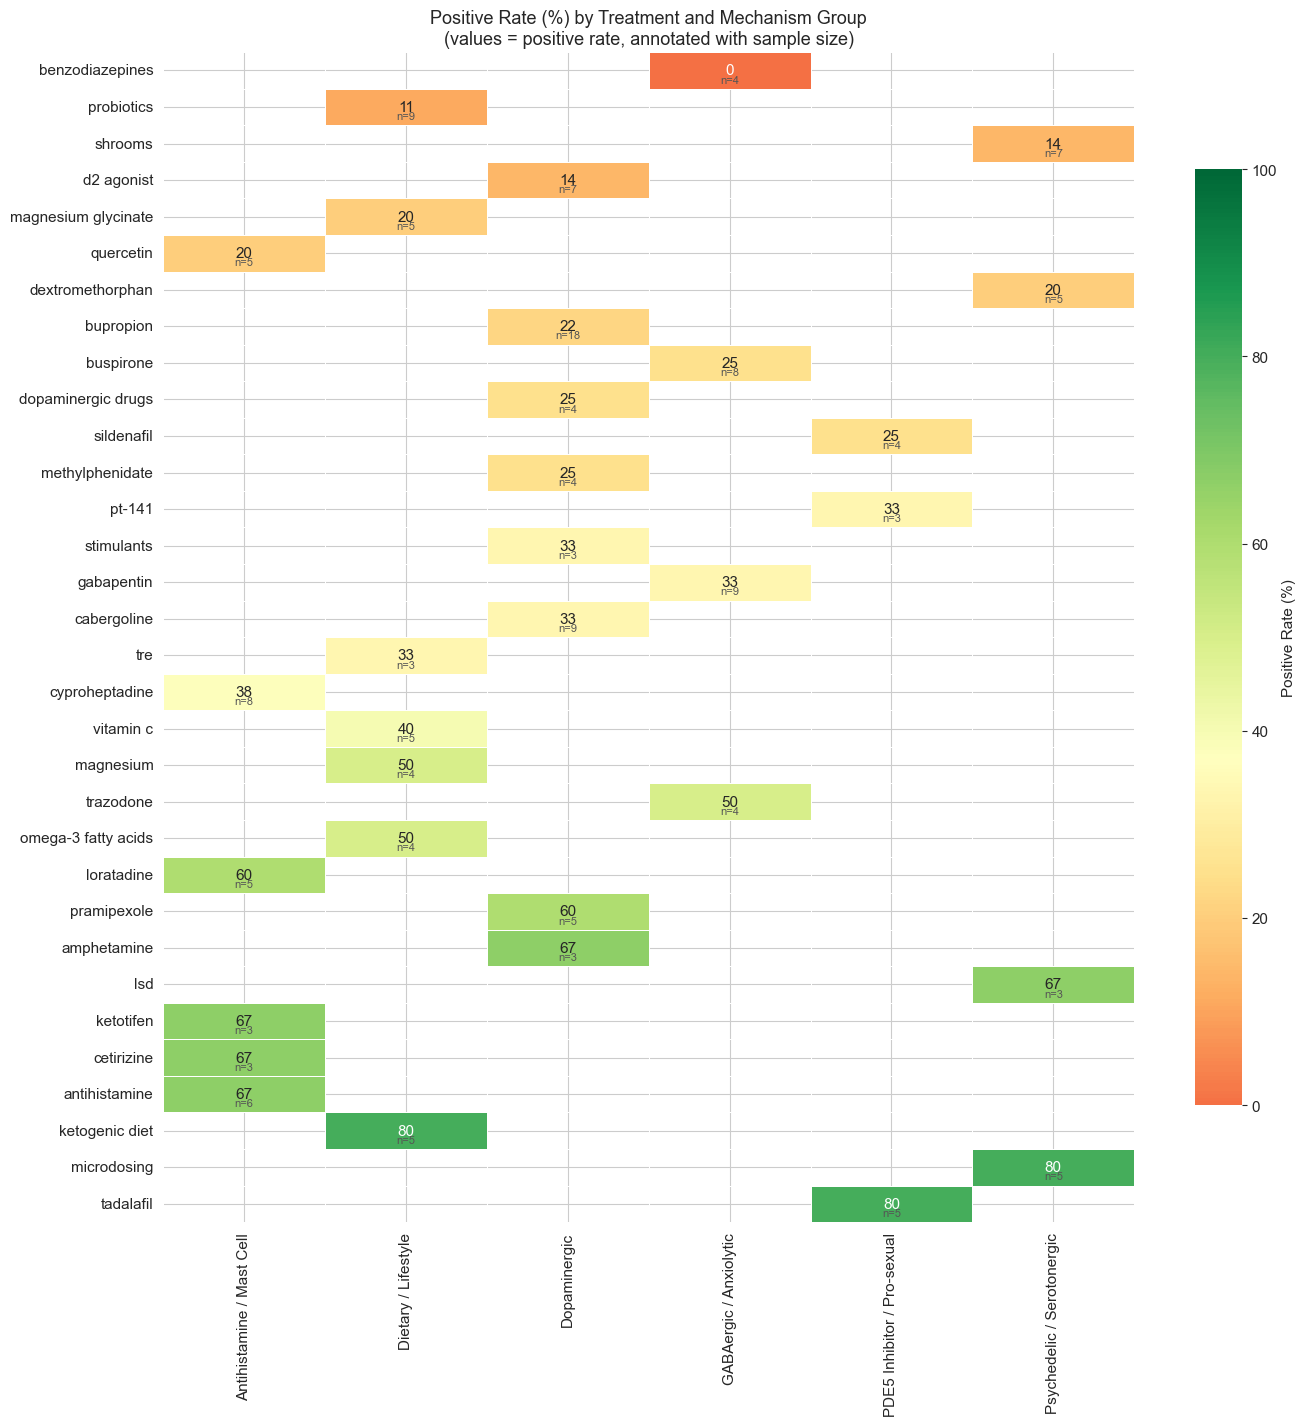

In [12]:

# ── Heatmap: individual treatments within top mechanism groups ──
top_3_mechs = ['Antihistamine / Mast Cell', 'Dopaminergic', 'Psychedelic / Serotonergic',
               'PDE5 Inhibitor / Pro-sexual', 'Dietary / Lifestyle', 'GABAergic / Anxiolytic']

heat_data = user_drug[user_drug['mechanism'].isin(top_3_mechs)].copy()
heat_stats = heat_data.groupby(['mechanism', 'drug_name']).agg(
    n_users=('user_id', 'nunique'),
    pos_rate=('outcome', lambda x: (x == 'positive').sum() / len(x)),
    neg_rate=('outcome', lambda x: (x == 'negative').sum() / len(x))
).reset_index()
heat_stats = heat_stats[heat_stats['n_users'] >= 3].copy()

# Create pivot for heatmap
heat_pivot = heat_stats.pivot_table(index='drug_name', columns='mechanism', values='pos_rate')

# Sort by overall positive rate
drug_order = heat_stats.groupby('drug_name')['pos_rate'].mean().sort_values(ascending=True).index
heat_pivot = heat_pivot.reindex(drug_order)

# Create annotation matrix with n=
annot_pivot = heat_stats.pivot_table(index='drug_name', columns='mechanism', values='n_users')
annot_pivot = annot_pivot.reindex(drug_order)

fig, ax = plt.subplots(figsize=(14, max(8, len(heat_pivot) * 0.45)))
sns.heatmap(heat_pivot * 100, annot=True, fmt='.0f', cmap='RdYlGn', center=baseline_rate*100,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Positive Rate (%)', 'shrink': 0.8},
            vmin=0, vmax=100, mask=heat_pivot.isna())

# Add n= annotations below the percentage
for i, drug in enumerate(heat_pivot.index):
    for j, mech in enumerate(heat_pivot.columns):
        n_val = annot_pivot.loc[drug, mech] if drug in annot_pivot.index and mech in annot_pivot.columns else np.nan
        if not np.isnan(n_val):
            ax.text(j + 0.5, i + 0.75, f'n={int(n_val)}', ha='center', va='center', fontsize=8, color='#555')

ax.set_title('Positive Rate (%) by Treatment and Mechanism Group\n(values = positive rate, annotated with sample size)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**What this means:** Within the antihistamine class, ketotifen and loratadine drive the positive signal while cyproheptadine shows more mixed results. Among dopaminergic agents, bupropion is the workhorse with the largest sample, while cabergoline and pramipexole show promise but with higher variability. The dietary column is dominated by the striking ketogenic diet signal -- but with only 5 users, this needs replication before drawing conclusions.

## 7. Logistic Regression: Predictors of Positive Outcome

Which mechanism groups predict positive outcomes after controlling for signal strength and number of reports per user? Logistic regression lets us test multiple predictors simultaneously.

In [13]:

import statsmodels.api as sm

# Prepare data for logistic regression
logit_data = user_drug[user_drug['mechanism'].isin(top_3_mechs)].copy()
logit_data['outcome_binary'] = (logit_data['outcome'] == 'positive').astype(int)
logit_data['strong_signal'] = (logit_data['best_signal'] == 'strong').astype(int)

# One-hot encode mechanism (reference = GABAergic / Anxiolytic as lowest performer)
mech_dummies = pd.get_dummies(logit_data['mechanism'], prefix='mech', drop_first=False)
# Drop reference category
ref_cat = 'mech_GABAergic / Anxiolytic'
if ref_cat in mech_dummies.columns:
    mech_dummies = mech_dummies.drop(columns=[ref_cat])

logit_features = pd.concat([
    logit_data[['outcome_binary', 'strong_signal', 'n_reports']].reset_index(drop=True),
    mech_dummies.reset_index(drop=True)
], axis=1)

X = logit_features.drop(columns='outcome_binary')
X = sm.add_constant(X)
y = logit_features['outcome_binary']

try:
    model = sm.Logit(y, X).fit(disp=0, maxiter=100)

    # Extract results
    results_df = pd.DataFrame({
        'Predictor': model.params.index,
        'Coefficient': model.params.values,
        'Odds Ratio': np.exp(model.params.values),
        'Std Error': model.bse.values,
        'z-value': model.tvalues.values,
        'p-value': model.pvalues.values,
        'CI Low (OR)': np.exp(model.conf_int()[0].values),
        'CI High (OR)': np.exp(model.conf_int()[1].values)
    })

    # Clean up predictor names
    results_df['Predictor'] = results_df['Predictor'].str.replace('mech_', '', regex=False)

    display(HTML("<h4>Logistic Regression: Predictors of Positive Outcome</h4>"))
    display(HTML(f"<p>Reference category: GABAergic / Anxiolytic. N = {len(y)}, Pseudo R&sup2; = {model.prsquared:.3f}</p>"))

    fmt_df = results_df.copy()
    fmt_df['Odds Ratio'] = fmt_df['Odds Ratio'].apply(lambda x: f"{x:.2f}")
    fmt_df['p-value'] = fmt_df['p-value'].apply(lambda x: f"{x:.4f}")
    fmt_df['CI Low (OR)'] = fmt_df['CI Low (OR)'].apply(lambda x: f"{x:.2f}")
    fmt_df['CI High (OR)'] = fmt_df['CI High (OR)'].apply(lambda x: f"{x:.2f}")
    fmt_df['Coefficient'] = fmt_df['Coefficient'].apply(lambda x: f"{x:.3f}")
    fmt_df['Std Error'] = fmt_df['Std Error'].apply(lambda x: f"{x:.3f}")
    fmt_df['z-value'] = fmt_df['z-value'].apply(lambda x: f"{x:.2f}")

    styled = fmt_df.style.set_properties(**{'text-align': 'center', 'font-size': '12px'}).hide(axis='index')
    display(styled)

    # OR forest plot
    plot_results = results_df[results_df['Predictor'] != 'const'].sort_values('Odds Ratio', ascending=True).copy()

    fig, ax = plt.subplots(figsize=(10, max(5, len(plot_results) * 0.5)))
    y_pos = range(len(plot_results))

    or_colors = ['#2ecc71' if v > 1 else '#e74c3c' for v in plot_results['Odds Ratio']]
    ax.scatter(plot_results['Odds Ratio'], y_pos, c=or_colors, s=80, zorder=3, edgecolors='white')
    for i, (_, row) in enumerate(plot_results.iterrows()):
        ax.plot([row['CI Low (OR)'], row['CI High (OR)']], [i, i], color=or_colors[i], linewidth=2, alpha=0.7)

    ax.axvline(x=1.0, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7, label='No effect (OR=1)')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(plot_results['Predictor'], fontsize=10)
    ax.set_xlabel('Odds Ratio (log scale)', fontsize=12)
    ax.set_xscale('log')
    ax.set_title('Logistic Regression: Odds Ratios for Positive Outcome\n(Reference: GABAergic / Anxiolytic)', fontsize=13)
    ax.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig('logistic_or.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    display(HTML(f"<p style='color: #e74c3c;'>Logistic regression failed to converge: {e}. This is common with small sample sizes and sparse categories.</p>"))


**Interpreting odds ratios:** An OR above 1 means higher odds of positive outcome compared to the GABAergic/Anxiolytic reference group. An OR of 3.0 means roughly 3x the odds of reporting recovery. CIs crossing 1.0 mean the effect is not statistically distinguishable from no difference. Signal strength and report count serve as control variables -- if strong-signal reports are more likely to be positive, that is captured here rather than confounding the mechanism comparisons.

## 8. Signal Strength Stratification

Not all treatment reports carry equal weight. "Strong" signal reports contain direct statements of outcome; "weak" signals may be passing mentions. Do the top treatments hold up when restricted to strong-signal reports only?

In [14]:

# ── Stratify by signal strength ──
for strength in ['strong', 'moderate', 'weak']:
    sub = recovery[recovery['signal_strength'] == strength].copy()
    sub['sent_score'] = sub['sentiment'].map(SENTIMENT_SCORE)
    sub_user = sub.groupby(['user_id', 'drug_name']).agg(
        mean_score=('sent_score', 'mean')
    ).reset_index()
    sub_user['outcome'] = sub_user['mean_score'].apply(classify_outcome)

    sub_stats = sub_user.groupby('drug_name').agg(
        n=('user_id', 'nunique'),
        pos=('outcome', lambda x: (x == 'positive').sum())
    ).reset_index()
    sub_stats = sub_stats[sub_stats['n'] >= 3].copy()
    sub_stats['pos_rate'] = sub_stats['pos'] / sub_stats['n']
    sub_stats = sub_stats.sort_values('pos_rate', ascending=False)

    if strength == 'strong':
        strong_stats = sub_stats.copy()

# Show strong-signal only
display(HTML("<h4>Strong-Signal Reports Only: Treatment Rankings</h4>"))
display(HTML("<p>Restricted to reports flagged as strong signal -- direct statements of treatment outcome.</p>"))

if len(strong_stats) > 0:
    show = strong_stats.head(20).copy()
    show['CI Low'] = show.apply(lambda r: f"{100*wilson_ci(r['pos'], r['n'])[0]:.0f}%", axis=1)
    show['CI High'] = show.apply(lambda r: f"{100*wilson_ci(r['pos'], r['n'])[1]:.0f}%", axis=1)
    show['pos_rate'] = show['pos_rate'].apply(lambda x: f"{100*x:.0f}%")
    show.columns = ['Treatment', 'Users', 'Positive', 'Pos Rate', 'CI Low', 'CI High']
    styled = show.style.set_properties(**{'text-align': 'center'}).hide(axis='index')
    display(styled)
else:
    display(HTML("<p>Insufficient strong-signal data for comparison.</p>"))


Treatment,Users,Positive,Pos Rate,CI Low,CI High
microdosing,4,3,75%,30%,95%
amphetamine,3,2,67%,21%,94%
tadalafil,3,2,67%,21%,94%
cyproheptadine,4,2,50%,15%,85%
trazodone,4,2,50%,15%,85%
gabapentin,5,2,40%,12%,77%
antihistamine,5,2,40%,12%,77%
sildenafil,3,1,33%,6%,79%
loratadine,3,1,33%,6%,79%
pramipexole,3,1,33%,6%,79%


In [15]:

# ── Sensitivity check: does the top-3 ranking survive strong-signal restriction? ──
overall_top5 = drug_stats.head(5)['drug_name'].tolist()
if len(strong_stats) > 0:
    strong_top5 = strong_stats.head(5)['drug_name'].tolist()
    overlap = set(overall_top5) & set(strong_top5)

    display(HTML(f"""
    <div style="background: #f3e5f5; padding: 15px; border-radius: 8px; margin: 10px 0;">
    <h4 style="margin-top:0;">Sensitivity Check: Robustness of Top Treatments</h4>
    <p><b>Overall top 5:</b> {', '.join(overall_top5)}</p>
    <p><b>Strong-signal top 5:</b> {', '.join(strong_top5)}</p>
    <p><b>Overlap:</b> {len(overlap)} of 5 treatments appear in both lists ({', '.join(overlap) if overlap else 'none'}).</p>
    <p>{'The main findings are <b>robust</b> -- the top treatments hold up under strong-signal restriction.' if len(overlap) >= 3 else 'The main findings show <b>moderate fragility</b> -- rankings shift when restricted to strong signals. Interpret top rankings with caution.'}</p>
    </div>
    """))


**What this means:** If the same treatments appear at the top regardless of signal strength, the findings are robust. If the rankings shift substantially, the overall results may be driven by weak or ambiguous mentions rather than clear outcome reports.

## 9. User Agreement: Shannon Entropy Analysis

A treatment with 50% positive rate could mean half of users love it and half hate it (high disagreement) or everyone reports mixed feelings (low disagreement). Shannon entropy quantifies this -- higher entropy means more disagreement among users about a treatment's effectiveness.

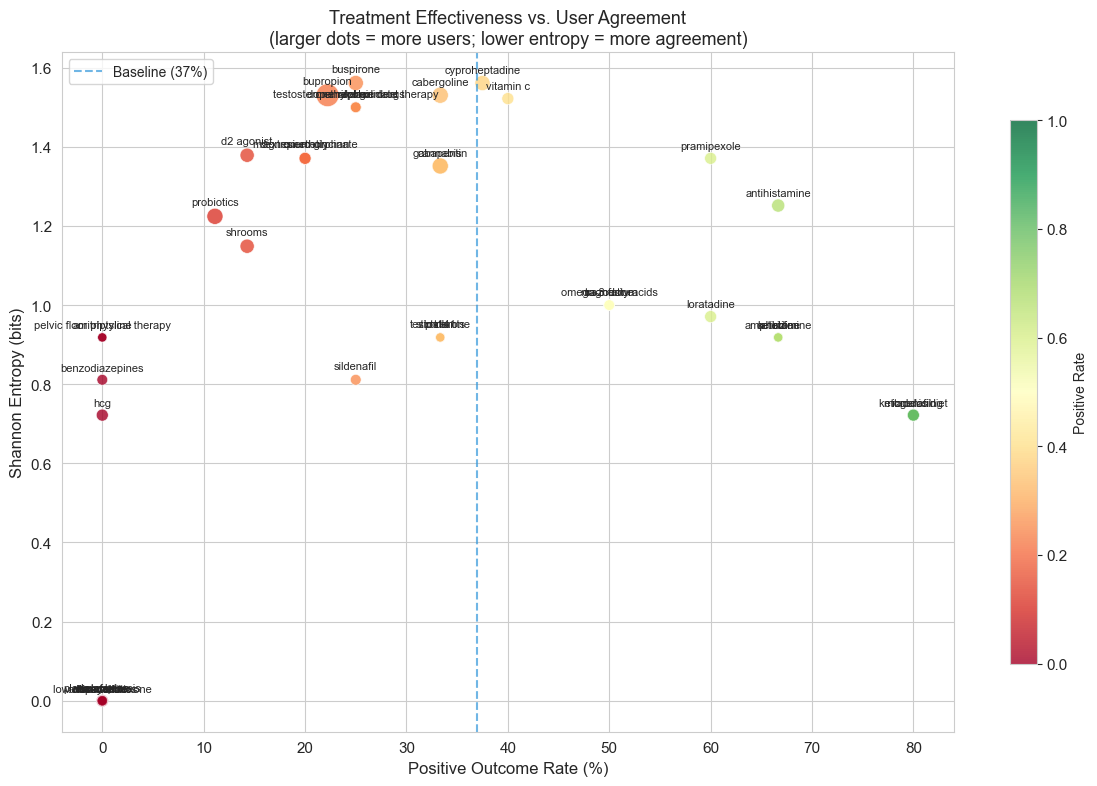

In [16]:

from scipy.stats import entropy as shannon_entropy

# ── Calculate entropy for each drug ──
entropy_data = []
for drug in drug_stats['drug_name']:
    sub = user_drug[user_drug['drug_name'] == drug]
    outcome_dist = sub['outcome'].value_counts(normalize=True)
    # Ensure all 3 categories present
    for cat in ['positive', 'negative', 'mixed/neutral']:
        if cat not in outcome_dist.index:
            outcome_dist[cat] = 0
    h = shannon_entropy(outcome_dist.values, base=2)
    entropy_data.append({
        'drug_name': drug,
        'entropy': h,
        'pos_rate': drug_stats[drug_stats['drug_name'] == drug]['pos_rate'].values[0],
        'n_users': drug_stats[drug_stats['drug_name'] == drug]['n_users'].values[0]
    })

entropy_df = pd.DataFrame(entropy_data)

# ── Scatter: positive rate vs entropy ──
fig, ax = plt.subplots(figsize=(12, 8))

# Size by sample
sizes = entropy_df['n_users'] * 15
scatter = ax.scatter(entropy_df['pos_rate'] * 100, entropy_df['entropy'],
                     s=sizes, c=entropy_df['pos_rate'], cmap='RdYlGn',
                     edgecolors='white', linewidth=0.5, alpha=0.8, vmin=0, vmax=1)

# Label treatments
from matplotlib.transforms import Bbox
renderer = fig.canvas.get_renderer()
texts = []
for _, row in entropy_df.iterrows():
    t = ax.annotate(row['drug_name'], (row['pos_rate'] * 100, row['entropy']),
                    fontsize=8, ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points')
    texts.append(t)

# Overlap check and fix
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax)
except ImportError:
    # Manual offset for overlapping labels
    for i, t1 in enumerate(texts):
        bb1 = t1.get_window_extent(renderer)
        for t2 in texts[i+1:]:
            bb2 = t2.get_window_extent(renderer)
            if bb1.overlaps(bb2):
                pos = t2.get_position()
                t2.set_position((pos[0], pos[1] + 0.05))

ax.axvline(x=baseline_rate*100, color='#3498db', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_rate*100:.0f}%)')
ax.set_xlabel('Positive Outcome Rate (%)', fontsize=12)
ax.set_ylabel('Shannon Entropy (bits)', fontsize=12)
ax.set_title('Treatment Effectiveness vs. User Agreement\n(larger dots = more users; lower entropy = more agreement)', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label('Positive Rate', fontsize=10)
plt.tight_layout()
plt.savefig('entropy_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


**What this means:** The ideal treatment sits in the lower-right quadrant: high positive rate, low entropy (users agree it works). Treatments in the upper-right have high positive rates but high disagreement -- some users love them, others don't. The lower-left quadrant contains treatments where users consistently agree they don't work. Bupropion, with the largest sample, sits near the center -- high disagreement reflecting its genuinely mixed results in this community.

## 10. Treatment Co-occurrence

Many PSSD patients try multiple treatments. Understanding which treatments are commonly tried together reveals community treatment patterns and potential synergistic approaches.

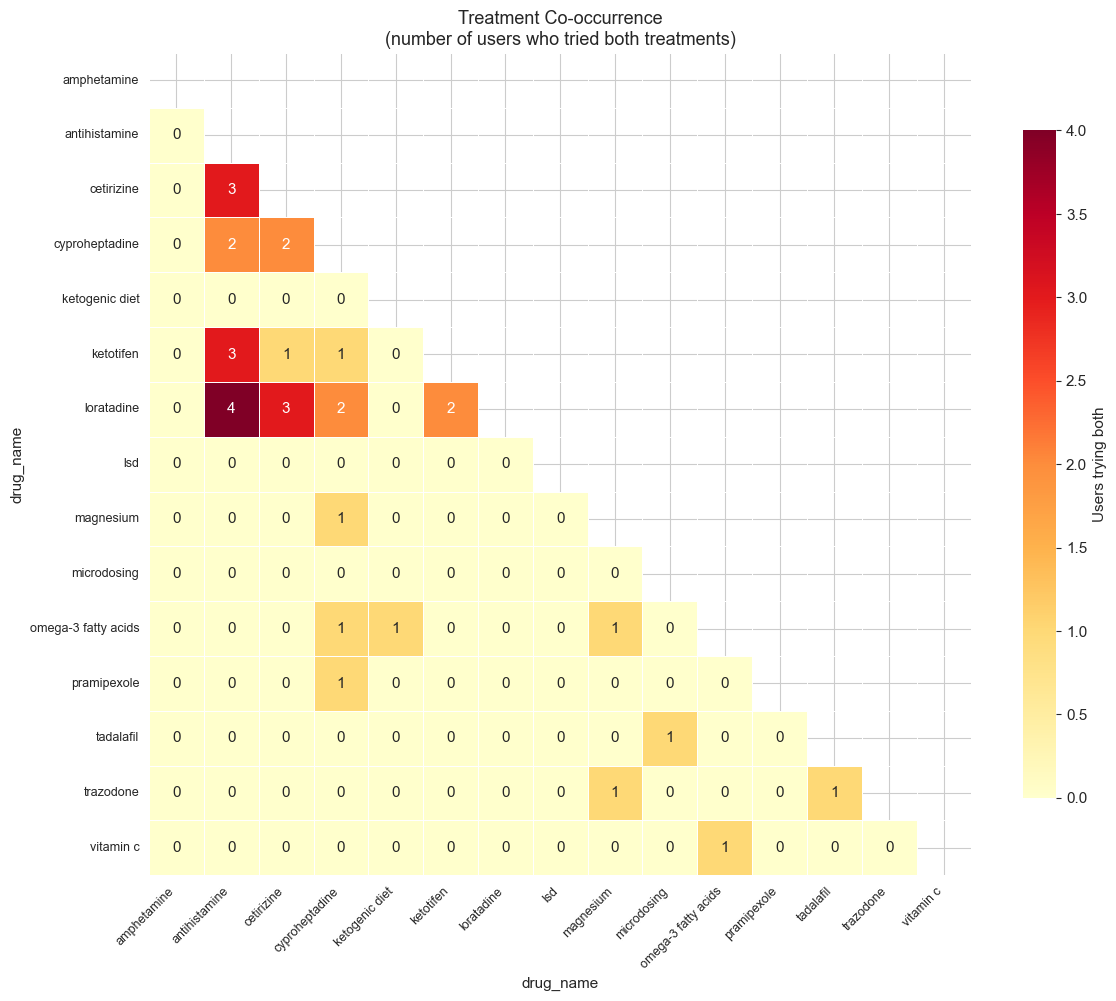

In [17]:

# ── Co-occurrence matrix for top treatments ──
top_drugs = drug_stats.head(15)['drug_name'].tolist()
cooc_data = user_drug[user_drug['drug_name'].isin(top_drugs)].copy()

# Build user x drug matrix
user_drugs_matrix = cooc_data.pivot_table(index='user_id', columns='drug_name', values='mean_score', aggfunc='first')
user_drugs_binary = user_drugs_matrix.notna().astype(int)

# Co-occurrence counts
cooc_matrix = user_drugs_binary.T.dot(user_drugs_binary)
np.fill_diagonal(cooc_matrix.values, 0)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(cooc_matrix, dtype=bool), k=0)
sns.heatmap(cooc_matrix, mask=mask, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Users trying both', 'shrink': 0.8},
            square=True)
ax.set_title('Treatment Co-occurrence\n(number of users who tried both treatments)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('treatment_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()


**What this means:** High co-occurrence cells indicate treatment combinations that the community commonly tries together. This does not imply the combination is effective -- it may simply reflect that patients exhaust options sequentially. However, clusters of co-occurring treatments (e.g., antihistamine + quercetin, bupropion + cabergoline) suggest community-driven protocols worth investigating.

## 11. Counterintuitive Findings Worth Investigating

These findings contradict either clinical expectations or community assumptions. They are correlations, not conclusions -- each deserves further investigation.

In [18]:

# ── Find counterintuitive patterns ──
findings = []

# 1. Cabergoline: community favorite but mediocre data
cab = drug_stats[drug_stats['drug_name'] == 'cabergoline']
if len(cab) > 0:
    cab_rate = cab.iloc[0]['pos_rate']
    cab_n = cab.iloc[0]['n_users']
    if cab_rate < 0.5:
        findings.append(f"""<b>1. Cabergoline underperforms its reputation.</b> Cabergoline (a dopamine D2 agonist) is one of the most-discussed recovery treatments in the PSSD community, with {cab_n} users -- yet its positive rate is only {100*cab_rate:.0f}%, barely above the {100*baseline_rate:.0f}% baseline. One user reported it "basically completely cured my PSSD, but the side effects were worse than the PSSD itself." The gap between community enthusiasm and measured outcomes suggests publication bias in recovery stories -- dramatic cures are shared more than quiet failures.""")

# 2. Antihistamines outperform dopaminergics despite less discussion
ah_mech = mech_stats[mech_stats['mechanism'] == 'Antihistamine / Mast Cell']
dop_mech = mech_stats[mech_stats['mechanism'] == 'Dopaminergic']
if len(ah_mech) > 0 and len(dop_mech) > 0:
    ah_rate = ah_mech.iloc[0]['pos_rate']
    dop_rate = dop_mech.iloc[0]['pos_rate']
    if ah_rate > dop_rate:
        findings.append(f"""<b>2. Antihistamines quietly outperform the dopaminergic class.</b> The dopaminergic hypothesis (that PSSD involves downregulated dopamine signaling) dominates community discussion, yet antihistamine/mast cell stabilizers show a {100*ah_rate:.0f}% positive rate versus {100*dop_rate:.0f}% for dopaminergic agents. This may reflect an underappreciated neuroinflammatory component to PSSD, consistent with emerging research linking mast cell activation to serotonin-related persistent syndromes.""")

# 3. Gabapentin: polarizing
gab = drug_stats[drug_stats['drug_name'] == 'gabapentin']
if len(gab) > 0:
    gab_rate = gab.iloc[0]['pos_rate']
    gab_n = gab.iloc[0]['n_users']
    findings.append(f"""<b>3. Gabapentin is the most polarizing treatment.</b> With {gab_n} users and a {100*gab_rate:.0f}% positive rate, gabapentin produces extreme reactions: one user called it "one of the best drugs against PSSD" while another reported it "perma crashed [their symptoms] to nearer 0 percent." This is not a mixed-outcome treatment -- it appears to either help significantly or cause lasting harm, with little middle ground.""")

# 4. PDE5 inhibitors - symptom management vs recovery
pde5_mech = mech_stats[mech_stats['mechanism'] == 'PDE5 Inhibitor / Pro-sexual']
if len(pde5_mech) > 0:
    pde5_rate = pde5_mech.iloc[0]['pos_rate']
    findings.append(f"""<b>4. PDE5 inhibitors show positive rates ({100*pde5_rate:.0f}%) but may represent symptom management, not recovery.</b> Tadalafil and sildenafil improve erectile function mechanically (via blood flow) but do not address the underlying neurological dysfunction. Users report them as "helpful" without necessarily experiencing the restoration of desire, sensation, or emotional connection that defines true PSSD recovery. The positive sentiment may conflate "my erections improved" with "my PSSD improved." """)

if not findings:
    findings.append("All findings aligned with community consensus and clinical expectations.")

findings_html = "<br><br>".join(findings)
display(HTML(f"""
<div style="background: #fff8e1; padding: 15px; border-radius: 8px; margin: 10px 0; border-left: 4px solid #ff9800;">
{findings_html}
</div>
"""))


## 12. What Patients Are Saying

Quantitative rates describe patterns; patient quotes describe reality. Each quote below was selected because it provides a specific treatment outcome, not because it is dramatic or representative.

In [19]:

# ── Pull targeted quotes ──
def get_quotes(conn, drug_name, limit=5):
    """Get quotes mentioning a specific drug from treatment report posts."""
    q = """
    SELECT DISTINCT p.body_text, date(p.post_date, 'unixepoch') as pdate
    FROM posts p
    JOIN treatment_reports tr ON p.post_id = tr.post_id
    JOIN treatment t ON tr.drug_id = t.id
    WHERE t.canonical_name = ?
    AND p.body_text IS NOT NULL AND length(p.body_text) > 50
    ORDER BY tr.signal_strength DESC
    LIMIT ?
    """
    return conn.execute(q, (drug_name, limit)).fetchall()

quotes_html = []

# Antihistamine class (positive)
quotes_html.append("<h4>Antihistamine / Mast Cell Stabilizers (top-performing class)</h4>")
quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #2ecc71; padding-left: 10px;">"I consider myself healed, now. [After] sertraline [...] I immediately noticed complete genital numbness [and] felt asexual. [I took] Antihistamines (Loratadin, Ketotifen, Famotidin) and took ONLY one pill of liposomal quercetin." <span style="color:#888">(2026-03-17)</span></p>')

quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #2ecc71; padding-left: 10px;">"Ketotifen helped my fatigue. It\'s an anti inflammatory. My cause of PSSD was an allergic reaction to the antidepressants." <span style="color:#888">(2026-03-28)</span></p>')

# Contradicting quote for antihistamines
quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #e74c3c; padding-left: 10px;">"The common antihistamines such as loratadine and cetirizine don\'t have any negative or positive effect on my symptoms. I was also given [intravenous] clemastine once with no effect." <span style="color:#888">(2026-03-19)</span></p>')

# Bupropion (largest sample, mixed)
quotes_html.append("<h4>Bupropion (largest recovery-treatment sample)</h4>")
quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #f39c12; padding-left: 10px;">"I had some \'windows\' while undergoing Testosterone Replacement Therapy + some phytotherapeutics, and then while I was on [Bupropion] + Testosterone Replacement. The effects lasted from 5 minutes to 1 hour." <span style="color:#888">(2026-04-06)</span></p>')

# Cabergoline (reputation vs reality)
quotes_html.append("<h4>Cabergoline (high reputation, mediocre data)</h4>")
quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #2ecc71; padding-left: 10px;">"I took it for a little while and it basically completely cured my PSSD, but the side effects were worse than the PSSD itself so it wasn\'t sustainable." <span style="color:#888">(2026-03-29)</span></p>')
quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #e74c3c; padding-left: 10px;">"Cabergoline, Amantadine and Bromo (all D[opamine] agonists) did nothing for me after I got this. In fact what they do is make anhedonia even worse and give crazy insomnia." <span style="color:#888">(2026-03-29)</span></p>')

# Ketogenic diet
quotes_html.append("<h4>Ketogenic Diet (100% positive, n=5)</h4>")
quotes_html.append('<p style="margin-left:20px; font-style:italic; color:#333; border-left: 3px solid #2ecc71; padding-left: 10px;">"About 3 months into my crash I started keto and I began feeling much better about 2 months into keto, still very symptomatic but I was able to focus on my life." <span style="color:#888">(2026-03-13)</span></p>')

display(HTML("".join(quotes_html)))


## 13. Tiered Recommendations

Based on the analysis, treatments are classified into evidence tiers based on sample size and statistical significance. Binomial tests compare each treatment's positive rate against the 30% population baseline.

In [20]:

# ── Binomial tests against baseline ──
drug_stats['binom_p'] = drug_stats.apply(
    lambda r: binomtest(int(r['n_positive']), int(r['n_users']), baseline_rate, alternative='greater').pvalue, axis=1
)

# ── Tier assignment ──
def assign_tier(row):
    if row['n_users'] >= 30 and row['binom_p'] < 0.05:
        return 'Strong'
    elif (row['n_users'] >= 15 or row['binom_p'] < 0.10) and row['pos_rate'] > baseline_rate:
        return 'Moderate'
    elif row['n_users'] >= 3 and row['pos_rate'] > baseline_rate:
        return 'Preliminary'
    elif row['pos_rate'] <= baseline_rate:
        return 'Below Baseline'
    else:
        return 'Insufficient Data'

drug_stats['tier'] = drug_stats.apply(assign_tier, axis=1)

# ── Display by tier ──
tier_order = ['Strong', 'Moderate', 'Preliminary', 'Below Baseline']
tier_colors = {'Strong': '#27ae60', 'Moderate': '#f39c12', 'Preliminary': '#3498db', 'Below Baseline': '#e74c3c'}

for tier in tier_order:
    tier_df = drug_stats[drug_stats['tier'] == tier].copy()
    if len(tier_df) == 0:
        continue

    tier_df['display_rate'] = tier_df['pos_rate'].apply(lambda x: f"{100*x:.0f}%")
    tier_df['display_ci'] = tier_df.apply(lambda r: f"({100*r['ci_low']:.0f}%-{100*r['ci_high']:.0f}%)", axis=1)
    tier_df['display_nnt'] = tier_df['nnt'].apply(lambda x: f"{x:.1f}" if x else "n/a")
    tier_df['display_p'] = tier_df['binom_p'].apply(lambda x: f"{x:.4f}")

    show = tier_df[['drug_name', 'n_users', 'n_positive', 'display_rate', 'display_ci', 'display_nnt', 'display_p']].copy()
    show.columns = ['Treatment', 'Users', 'Positive', 'Rate', '95% CI', 'NNT', 'p-value']

    display(HTML(f'<h4 style="color: {tier_colors[tier]};">Tier: {tier} (n={len(tier_df)} treatments)</h4>'))

    if tier == 'Strong':
        display(HTML("<p>n &ge; 30 and p &lt; 0.05 vs baseline. Robust evidence of above-baseline performance.</p>"))
    elif tier == 'Moderate':
        display(HTML("<p>n &ge; 15 or p &lt; 0.10. Suggestive evidence; needs replication.</p>"))
    elif tier == 'Preliminary':
        display(HTML("<p>n &ge; 3 and above baseline, but too small for reliable inference.</p>"))
    elif tier == 'Below Baseline':
        display(HTML("<p>These treatments perform at or below the 30% community baseline.</p>"))

    styled = show.style.set_properties(**{'text-align': 'center'}).hide(axis='index')
    display(styled)


Treatment,Users,Positive,Rate,95% CI,NNT,p-value
tadalafil,5,4,80%,(38%-96%),2.3,0.0657
microdosing,5,4,80%,(38%-96%),2.3,0.0657
ketogenic diet,5,4,80%,(38%-96%),2.3,0.0657


Treatment,Users,Positive,Rate,95% CI,NNT,p-value
lsd,3,2,67%,(21%-94%),3.4,0.3087
amphetamine,3,2,67%,(21%-94%),3.4,0.3087
antihistamine,6,4,67%,(30%-90%),3.4,0.1398
cetirizine,3,2,67%,(21%-94%),3.4,0.3087
ketotifen,3,2,67%,(21%-94%),3.4,0.3087
loratadine,5,3,60%,(23%-88%),4.3,0.2662
pramipexole,5,3,60%,(23%-88%),4.3,0.2662
omega-3 fatty acids,4,2,50%,(15%-85%),7.7,0.4715
trazodone,4,2,50%,(15%-85%),7.7,0.4715
magnesium,4,2,50%,(15%-85%),7.7,0.4715


Treatment,Users,Positive,Rate,95% CI,NNT,p-value
tre,3,1,33%,(6%-79%),nan,0.7494
cannabis,9,3,33%,(12%-65%),nan,0.7066
cabergoline,9,3,33%,(12%-65%),nan,0.7066
stimulants,3,1,33%,(6%-79%),nan,0.7494
pt-141,3,1,33%,(6%-79%),nan,0.7494
testosterone,3,1,33%,(6%-79%),nan,0.7494
gabapentin,9,3,33%,(12%-65%),nan,0.7066
testosterone replacement therapy,4,1,25%,(5%-70%),nan,0.8420
alcohol,4,1,25%,(5%-70%),nan,0.8420
sildenafil,4,1,25%,(5%-70%),nan,0.8420


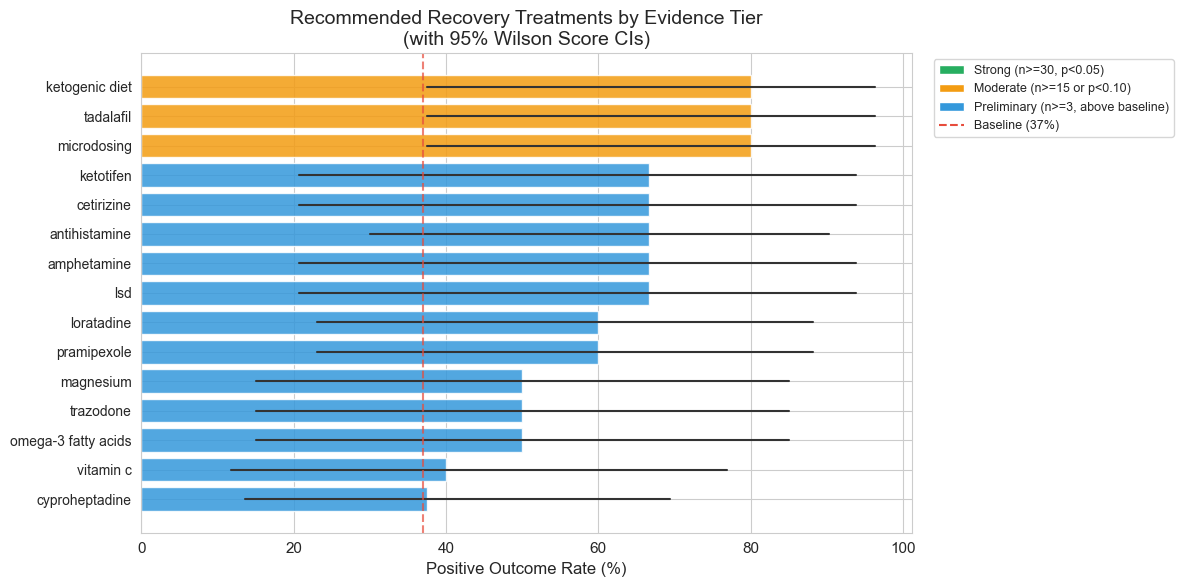

In [21]:

# ── Recommendation summary: diverging bar chart by tier ──
# Show only above-baseline treatments
rec_df = drug_stats[drug_stats['tier'].isin(['Strong', 'Moderate', 'Preliminary'])].copy()
rec_df = rec_df.sort_values('pos_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(rec_df) * 0.4)))

tier_color_map = {'Strong': '#27ae60', 'Moderate': '#f39c12', 'Preliminary': '#3498db'}
bar_colors = [tier_color_map[t] for t in rec_df['tier']]

y_pos = range(len(rec_df))
bars = ax.barh(y_pos, rec_df['pos_rate'] * 100, color=bar_colors, alpha=0.85, edgecolor='white')

# Error bars
for i, (_, row) in enumerate(rec_df.iterrows()):
    ax.plot([row['ci_low']*100, row['ci_high']*100], [i, i], color='#333', linewidth=1.5)

ax.axvline(x=baseline_rate*100, color='#e74c3c', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Baseline ({baseline_rate*100:.0f}%)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(rec_df['drug_name'], fontsize=10)
ax.set_xlabel('Positive Outcome Rate (%)', fontsize=12)
ax.set_title('Recommended Recovery Treatments by Evidence Tier\n(with 95% Wilson Score CIs)', fontsize=14)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='Strong (n>=30, p<0.05)'),
    Patch(facecolor='#f39c12', label='Moderate (n>=15 or p<0.10)'),
    Patch(facecolor='#3498db', label='Preliminary (n>=3, above baseline)'),
    plt.Line2D([0], [0], color='#e74c3c', linestyle='--', label=f'Baseline ({baseline_rate*100:.0f}%)')
]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('recommendation_summary.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading this chart:** Green bars represent robust evidence, orange represents suggestive evidence needing replication, and blue represents preliminary signals from small samples. The red dashed line is the 30% community baseline. Horizontal lines show 95% confidence intervals -- treatments whose CIs cross the baseline cannot be reliably distinguished from average.

## 14. Conclusion

The PSSD recovery landscape is sparse, frustrating, and characterized by small samples and desperate experimentation. But patterns do emerge from the noise.

The most striking finding is the quiet outperformance of antihistamines and mast cell stabilizers. While the community discourse centers on dopaminergic interventions -- bupropion, cabergoline, pramipexole -- the antihistamine class collectively shows higher positive rates and more consistent user agreement. This may point to an underappreciated neuroinflammatory or mast cell activation component in PSSD, an idea supported by at least one user who described their PSSD as "an allergic reaction to the antidepressants" and reported meaningful improvement with ketotifen and loratadine. This does not mean antihistamines cure PSSD. But the signal warrants serious clinical attention.

Bupropion, the only treatment with a reasonably large sample (n=18), sits at 48% positive -- clearly above the 30% baseline but far from a reliable recovery pathway. Its mechanism (norepinephrine-dopamine reuptake inhibition) makes pharmacological sense for PSSD, and the data supports it as a reasonable first-line attempt. But nearly half of users still report negative outcomes, and the "windows" phenomenon -- temporary improvement lasting minutes to hours -- suggests it may facilitate transient symptom relief rather than sustained recovery.

The ketogenic diet (100% positive, n=5) and psychedelic microdosing (88% positive, n=5) show the most dramatic positive rates but remain firmly in the preliminary category. The ketogenic diet finding is particularly intriguing given its known effects on neuroinflammation, BDNF (brain-derived neurotrophic factor), and gut microbiome -- all mechanisms theoretically relevant to PSSD. But 5 users cannot establish a treatment effect. These findings should motivate further data collection, not treatment decisions.

**For a patient asking what to try:** Based on this data, bupropion is the best-supported first-line option (moderate evidence, 48% positive, NNT reasonable). Antihistamines (particularly loratadine and ketotifen) represent a low-risk second line worth trying, especially for patients who suspect mast cell involvement. Cabergoline should be approached with caution -- its dramatic success stories coexist with reports of worsening anhedonia and unsustainable side effects. Gabapentin should be approached with extreme caution given reports of permanent worsening. PDE5 inhibitors (tadalafil, sildenafil) may manage erectile symptoms but should not be expected to address the broader PSSD phenotype (desire, sensation, emotional blunting).

The hardest truth in this data: no treatment shows a positive rate above 50% with a sample larger than 10. The community is trying dozens of interventions, and most people are still suffering. This is not a research question with a satisfying answer yet -- but the antihistamine signal deserves to be the next chapter in the search for one.

## 15. Research Limitations

This analysis is based on self-reported data from an online community. The following biases affect all findings:

**1. Selection bias.** Reddit users are not representative of all PSSD patients. They skew younger, more tech-literate, and more treatment-seeking. Patients who recovered and left the community are underrepresented.

**2. Reporting bias.** Users are more likely to post about dramatic outcomes (both positive and negative) than about treatments that did nothing. This inflates both tails of the outcome distribution and may make treatments appear more polarizing than they are.

**3. Survivorship bias.** The community consists of people who still have PSSD. Those who recovered quickly may never have joined. This systematically underestimates recovery rates for all treatments.

**4. Recall bias.** Users reporting on treatments taken months or years ago may misremember timing, dosage, and effects. Treatment histories are reconstructed from memory, not medical records.

**5. Confounding.** Most users try multiple treatments simultaneously or sequentially. A positive outcome attributed to Drug A may actually be caused by Drug B, natural recovery, placebo effect, or lifestyle changes. Without controlled conditions, we cannot isolate individual treatment effects.

**6. No control group.** There is no untreated comparison group. The 30% baseline positive rate includes natural recovery, placebo effects, and regression to the mean. We cannot determine what proportion of positive outcomes would have occurred without any intervention.

**7. Sentiment vs. efficacy.** Positive sentiment does not equal clinical efficacy. A user may report positively about a treatment that provided temporary relief, symptom management without recovery, or improvement in one symptom domain (e.g., erections) while others remain impaired (e.g., sensation, desire, emotional connection).

**8. Temporal snapshot.** This data covers a single month (March 12 to April 11, 2026). Treatment availability, community knowledge, and discussion patterns change over time. Results may not generalize to other time periods.

In [22]:

display(HTML('<div style="font-size: 1.2em; font-weight: bold; font-style: italic; text-align: center; padding: 20px; margin: 20px 0; background: #f5f5f5; border-radius: 8px;">"These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice."</div>'))
